# Free Vibration — complete slide-methode

Deze notebook volgt de opzet van de bestaande Free_Vibration-notebook,
maar maakt de vrije-trillingsanalyse volledig en robuust volgens de slide-methode:
- 2-segment Euler-Bernoulli oplossing (onder/boven water)
- boundary/interface matrix K(ω)
- natuurlijke frequenties via singular-value minima
- eerste 3 modusvormen

In [1]:
import sympy as sp
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Numerieke invoer (zelfde stijl als Free_Vibration)
# -----------------------------
g_num = 9.81
h_num = 35.0
H_num = 150.0
D_num = 8.0
t_num = 0.1

M_num = 1e6
J_num = 1.6e9
c_num = 30e3

E_num = 210e9
rho_num = 7850.0
rho_f_num = 1025.0
Ca_num = 0.7

T_num = 0.0

Di_num = D_num - 2.0*t_num
A_num = math.pi/4.0 * (D_num**2 - Di_num**2)
I_num = math.pi/64.0 * (D_num**4 - Di_num**4)
EI_num = E_num * I_num

m1_num = rho_num*A_num + rho_f_num*Ca_num*math.pi*D_num**2/4.0
m2_num = rho_num*A_num

print(f"A = {A_num:.6f} m^2, I = {I_num:.6f} m^4")
print(f"m1 (submerged) = {m1_num:.3f} kg/m")
print(f"m2 (above water) = {m2_num:.3f} kg/m")

A = 2.481858 m^2, I = 19.364699 m^4
m1 (submerged) = 55548.071 kg/m
m2 (above water) = 19482.587 kg/m


In [3]:
# -----------------------------
# Symbolen en algemene oplossingen (slide-methode)
# -----------------------------
z, omega = sp.symbols('z omega', real=True, positive=True)
E, I, T = sp.symbols('E I T', positive=True, real=True)
rho, A = sp.symbols('rho A', positive=True, real=True)
rho_f, Ca, D = sp.symbols('rho_f Ca D', positive=True, real=True)
h, H = sp.symbols('h H', positive=True, real=True)
J, Mtip, c = sp.symbols('J M c', real=True)
EI = E*I

m1 = rho*A + rho_f*Ca*sp.pi*D**2/4
m2 = rho*A

beta1_4 = (omega**2 * m1) / EI
beta2_4 = (omega**2 * m2) / EI

alpha1_sq = ( T/EI + sp.sqrt((T/EI)**2 + 4*beta1_4))/2
mu1_sq    = (-T/EI + sp.sqrt((T/EI)**2 + 4*beta1_4))/2
alpha2_sq = ( T/EI + sp.sqrt((T/EI)**2 + 4*beta2_4))/2
mu2_sq    = (-T/EI + sp.sqrt((T/EI)**2 + 4*beta2_4))/2

alpha1, mu1 = sp.sqrt(alpha1_sq), sp.sqrt(mu1_sq)
alpha2, mu2 = sp.sqrt(alpha2_sq), sp.sqrt(mu2_sq)

A1,B1,C1,D1 = sp.symbols('A1 B1 C1 D1')
A2,B2,C2,D2 = sp.symbols('A2 B2 C2 D2')

W1 = A1*sp.cosh(alpha1*z) + B1*sp.sinh(alpha1*z) + C1*sp.cos(mu1*z) + D1*sp.sin(mu1*z)
W2 = A2*sp.cosh(alpha2*z) + B2*sp.sinh(alpha2*z) + C2*sp.cos(mu2*z) + D2*sp.sin(mu2*z)

W1_1, W1_2, W1_3 = sp.diff(W1, z), sp.diff(W1, z, 2), sp.diff(W1, z, 3)
W2_1, W2_2, W2_3 = sp.diff(W2, z), sp.diff(W2, z, 2), sp.diff(W2, z, 3)

In [4]:
# -----------------------------
# Boundary/interface matrix K(ω)
# -----------------------------
eq1 = W1.subs(z, -h)
eq2 = W1_1.subs(z, -h)

eq3 = W1.subs(z, 0)  - W2.subs(z, 0)
eq4 = W1_1.subs(z, 0) - W2_1.subs(z, 0)
eq5 = W1_2.subs(z, 0) - W2_2.subs(z, 0)
eq6 = W1_3.subs(z, 0) - W2_3.subs(z, 0)

eq7 = EI*W2_2.subs(z, H) - J*omega**2*W2_1.subs(z, H)
eq8 = EI*W2_3.subs(z, H) + Mtip*omega**2*W2.subs(z, H)

eqs = [eq1,eq2,eq3,eq4,eq5,eq6,eq7,eq8]
Cvec = sp.Matrix([A1,B1,C1,D1,A2,B2,C2,D2])
K = sp.Matrix([[sp.diff(expr, cst) for cst in Cvec] for expr in eqs])

vals = {
    E: E_num, I: I_num, T: T_num,
    rho: rho_num, A: A_num,
    rho_f: rho_f_num, Ca: Ca_num, D: D_num,
    h: h_num, H: H_num,
    J: J_num, Mtip: M_num, c: 0.0
}

K_w = sp.simplify(K.subs(vals))
K_fun = sp.lambdify(omega, K_w, modules='numpy')

def Knum(w):
    return np.array(K_fun(float(w)), dtype=np.complex128)

def sigma_min(w):
    s = np.linalg.svd(Knum(w), compute_uv=False)
    return float(np.min(s))

Eerste 3 natuurlijke frequenties:
mode 1: omega = 0.991297 rad/s | f = 0.157770 Hz | sigma_min = 5.12e-12
mode 2: omega = 5.360280 rad/s | f = 0.853115 Hz | sigma_min = 3.80e-11
mode 3: omega = 12.957803 rad/s | f = 2.062298 Hz | sigma_min = 2.51e-09


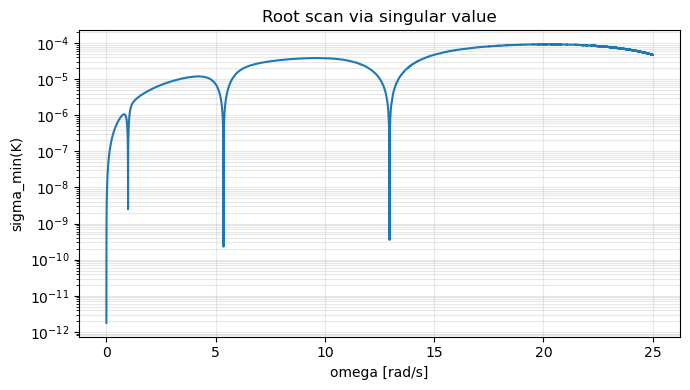

In [7]:
# -----------------------------
# Natuurlijke frequenties via minima van sigma_min(ω)
# -----------------------------
def golden_minimize(f, a, b, n_iter=70):
    gr = (np.sqrt(5.0) - 1.0) / 2.0
    c1 = b - gr*(b-a)
    c2 = a + gr*(b-a)
    f1 = f(c1)
    f2 = f(c2)
    for _ in range(n_iter):
        if f1 < f2:
            b, c2, f2 = c2, c1, f1
            c1 = b - gr*(b-a)
            f1 = f(c1)
        else:
            a, c1, f1 = c1, c2, f2
            c2 = a + gr*(b-a)
            f2 = f(c2)
    x = 0.5*(a+b)
    return x, f(x)

def find_modes(n_modes=3, omega_max=25.0, n_grid=25000, sigma_tol=1e-8, min_spacing=5e-2):
    ws = np.linspace(1e-4, omega_max, n_grid)
    sig = np.array([sigma_min(w) for w in ws], dtype=float)

    refined = []
    for i in range(1, len(ws)-1):
        if sig[i] < sig[i-1] and sig[i] < sig[i+1]:
            a, b = ws[i-1], ws[i+1]
            w_star, s_star = golden_minimize(sigma_min, a, b)
            refined.append((float(w_star), float(s_star)))

    refined.sort(key=lambda t: t[0])
    unique = []
    for w_star, s_star in refined:
        if not unique or abs(w_star - unique[-1][0]) > min_spacing:
            unique.append((w_star, s_star))
        elif s_star < unique[-1][1]:
            unique[-1] = (w_star, s_star)

    physical = [(w, s) for (w, s) in unique if s < sigma_tol]
    physical.sort(key=lambda t: t[0])

    om = np.array([w for w, _ in physical[:n_modes]], dtype=float)
    sm = np.array([s for _, s in physical[:n_modes]], dtype=float)
    return om, sm, ws, sig

omega_n, sigma_n, omega_scan, sig_scan = find_modes(n_modes=3, sigma_tol=1e-8)
freq_n = omega_n/(2*np.pi)

print('Eerste 3 natuurlijke frequenties:')
for i, (om, fr, sg) in enumerate(zip(omega_n, freq_n, sigma_n), 1):
    print(f"mode {i}: omega = {om:.6f} rad/s | f = {fr:.6f} Hz | sigma_min = {sg:.2e}")

if len(omega_n) < 3:
    print(f"Waarschuwing: slechts {len(omega_n)} fysieke roots gevonden onder sigma_tol = 1e-8.")

plt.figure(figsize=(7,4))
plt.plot(omega_scan, sig_scan)
plt.yscale('log')
plt.xlabel('omega [rad/s]')
plt.ylabel('sigma_min(K)')
plt.title('Root scan via singular value')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

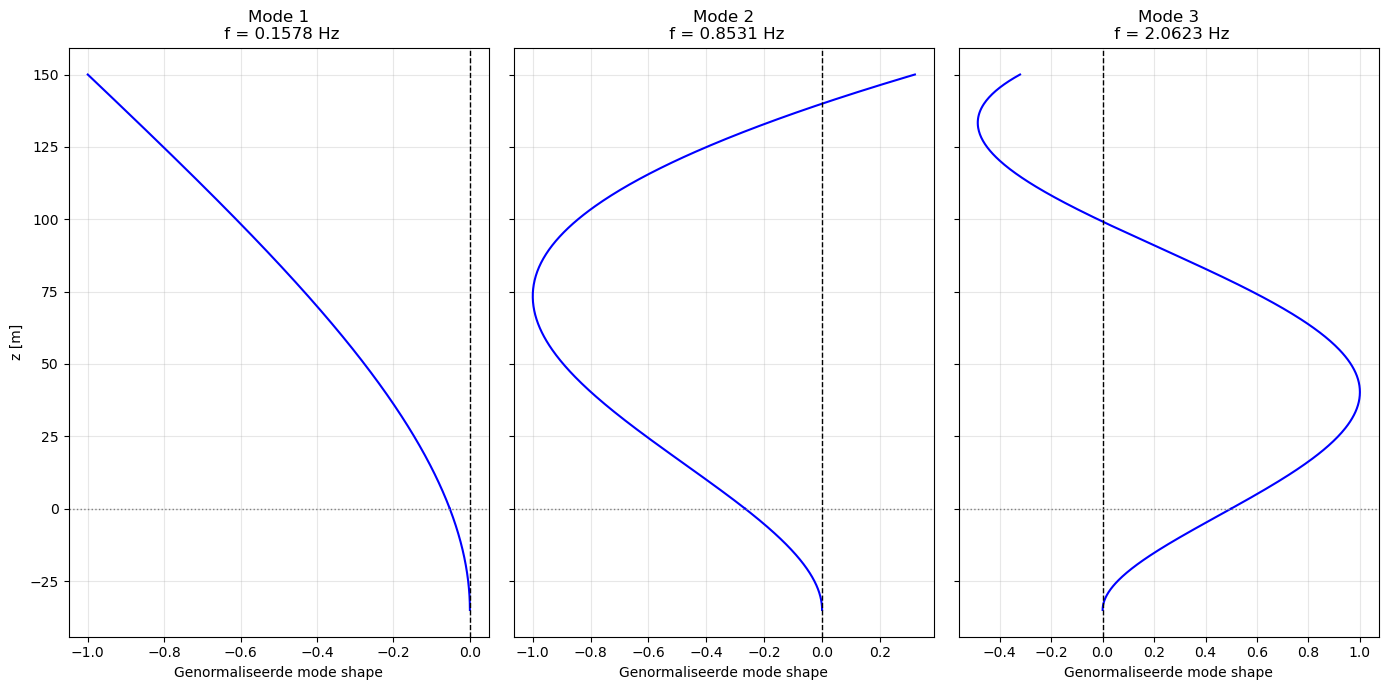

In [8]:
# -----------------------------
# Eerste 3 modusvormen
# -----------------------------
W1_num = sp.simplify(W1.subs(vals))
W2_num = sp.simplify(W2.subs(vals))

W1_fun = sp.lambdify((z, omega, A1,B1,C1,D1,A2,B2,C2,D2), W1_num, 'numpy')
W2_fun = sp.lambdify((z, omega, A1,B1,C1,D1,A2,B2,C2,D2), W2_num, 'numpy')

def mode_constants(om):
    Kw = Knum(om)
    _, _, Vh = np.linalg.svd(Kw)
    cst = Vh.conj().T[:, -1]
    return cst/(np.max(np.abs(cst)) + 1e-16)

z1 = np.linspace(-h_num, 0.0, 300)
z2 = np.linspace(0.0, H_num, 400)

fig, axes = plt.subplots(1, 3, figsize=(14, 7), sharey=True)
for i, om in enumerate(omega_n[:3]):
    cst = mode_constants(om)
    A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v = cst

    phi1 = np.real(np.array(W1_fun(z1, om, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v), dtype=np.complex128))
    phi2 = np.real(np.array(W2_fun(z2, om, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v), dtype=np.complex128))

    norm = max(np.max(np.abs(phi1)), np.max(np.abs(phi2))) + 1e-16
    phi1 /= norm
    phi2 /= norm

    ax = axes[i]
    ax.plot(phi1, z1, 'b')
    ax.plot(phi2, z2, 'b')
    ax.axvline(0.0, color='k', linestyle='--', linewidth=1)
    ax.axhline(0.0, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Mode {i+1}\n f = {om/(2*np.pi):.4f} Hz")
    ax.set_xlabel('Genormaliseerde mode shape')

axes[0].set_ylabel('z [m]')
plt.tight_layout()
plt.show()

### Opmerking
Voor vrije trillingen is demping niet meegenomen in de eigenwaarde-bepaling (c=0).
Dit is in lijn met de standaard slide-methode voor natuurlijke frequenties en modusvormen.

## Steady-state (slide-only)
Hieronder wordt de stationaire respons berekend met **alleen** de slide-modale methode (geen FEM), voor:
- regelmatige golf
- JONSWAP
- zonder en met top-dashpot

In [9]:
# -----------------------------
# Steady-state instellingen + golfhelpers
# -----------------------------
Hs = 6.0
Tp = 12.0
Cm = 2.0
gamma_jonswap = 3.3

A_disp = np.pi * D_num**2 / 4.0
n_modes_ss = min(3, len(omega_n))

def solve_dispersion(omega_w, h_w, g_w=9.81):
    k = omega_w**2 / g_w
    for _ in range(80):
        f = g_w * k * np.tanh(k * h_w) - omega_w**2
        df = g_w * np.tanh(k * h_w) + g_w * k * h_w * (1 / np.cosh(k * h_w))**2
        k_new = k - f / (df + 1e-18)
        if abs(k_new - k) < 1e-13:
            break
        k = k_new
    return float(k)

def regular_wave_line_load_amp(zq, omega_w, a_wave):
    k = solve_dispersion(omega_w, h_num, g_num)
    u_ddot = a_wave * omega_w**2 * np.cosh(k * (zq + h_num)) / np.sinh(k * h_num)
    return rho_f_num * Cm * A_disp * u_ddot

def jonswap(f, Hs_loc, Tp_loc, gamma=3.3):
    fp = 1.0 / Tp_loc
    alpha = 0.0624 / (0.230 + 0.0336 * gamma - 0.185 * (1.9 + gamma)**-1)
    sigma = np.where(f <= fp, 0.07, 0.09)
    r = np.exp(-0.5 * ((f - fp) / (sigma * fp))**2)
    S = (alpha * Hs_loc**2 * fp**4 * f**-5
         * np.exp(-1.25 * (fp / f)**4)
         * gamma**r)
    return S

In [10]:
# -----------------------------
# Slide-modale projectie voor steady-state
# -----------------------------
W1p_num = sp.simplify(W1_1.subs(vals))
W2p_num = sp.simplify(W2_1.subs(vals))

W1p_fun = sp.lambdify((z, omega, A1,B1,C1,D1,A2,B2,C2,D2), W1p_num, 'numpy')
W2p_fun = sp.lambdify((z, omega, A1,B1,C1,D1,A2,B2,C2,D2), W2p_num, 'numpy')

def eval_mode_shape(zq, om, cst):
    A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v = cst
    z_arr = np.atleast_1d(np.array(zq, dtype=float))
    out = np.zeros_like(z_arr, dtype=np.complex128)

    mask1 = z_arr <= 0.0
    mask2 = ~mask1

    if np.any(mask1):
        out[mask1] = np.array(W1_fun(z_arr[mask1], om, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v), dtype=np.complex128)
    if np.any(mask2):
        out[mask2] = np.array(W2_fun(z_arr[mask2], om, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v), dtype=np.complex128)

    if np.isscalar(zq):
        return out[0]
    return out

def eval_mode_slope(zq, om, cst):
    A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v = cst
    z_arr = np.atleast_1d(np.array(zq, dtype=float))
    out = np.zeros_like(z_arr, dtype=np.complex128)

    mask1 = z_arr <= 0.0
    mask2 = ~mask1

    if np.any(mask1):
        out[mask1] = np.array(W1p_fun(z_arr[mask1], om, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v), dtype=np.complex128)
    if np.any(mask2):
        out[mask2] = np.array(W2p_fun(z_arr[mask2], om, A1v,B1v,C1v,D1v,A2v,B2v,C2v,D2v), dtype=np.complex128)

    if np.isscalar(zq):
        return out[0]
    return out

z_sub = np.linspace(-h_num, 0.0, 1000)
z_air = np.linspace(0.0, H_num, 1000)
z_wet = np.linspace(-h_num, 0.0, 1200)

modal_data = []
for r in range(n_modes_ss):
    om_r = float(omega_n[r])
    cst_r = mode_constants(om_r)

    phi_top = np.real(eval_mode_shape(H_num, om_r, cst_r))
    scl = 1.0 / (phi_top + 1e-16)

    phi_sub = np.real(eval_mode_shape(z_sub, om_r, cst_r) * scl)
    phi_air = np.real(eval_mode_shape(z_air, om_r, cst_r) * scl)
    phi_wet = np.real(eval_mode_shape(z_wet, om_r, cst_r) * scl)

    phi_prime_top = float(np.real(eval_mode_slope(H_num, om_r, cst_r) * scl))
    phi_swl = float(np.real(eval_mode_shape(0.0, om_r, cst_r) * scl))

    m_gen = (
        np.trapezoid(m1_num * phi_sub**2, z_sub)
        + np.trapezoid(m2_num * phi_air**2, z_air)
        + M_num * 1.0**2
        + J_num * phi_prime_top**2
    )
    k_gen = m_gen * om_r**2
    c_gen = c_num * 1.0**2

    modal_data.append({
        'omega': om_r,
        'cst': cst_r,
        'm': float(m_gen),
        'k': float(k_gen),
        'c': float(c_gen),
        'phi_swl': phi_swl,
        'phi_top': 1.0,
        'phi_wet': phi_wet
    })

def slide_harmonic_response(Tp_loc, with_dashpot=False, a_wave=None, phase=0.0):
    om = 2.0 * np.pi / Tp_loc
    a_loc = Hs / 2.0 if a_wave is None else a_wave
    p_wet = regular_wave_line_load_amp(z_wet, om, a_loc)

    q_hat = np.zeros(n_modes_ss, dtype=np.complex128)
    for r in range(n_modes_ss):
        mr = modal_data[r]['m']
        kr = modal_data[r]['k']
        cr = modal_data[r]['c']
        phi_wet = modal_data[r]['phi_wet']

        Q_hat = np.trapezoid(p_wet * phi_wet, z_wet) * np.exp(1j * phase)
        den = kr - om**2 * mr
        if with_dashpot:
            den = den + 1j * om * cr
        den = den + 1e-12
        q_hat[r] = Q_hat / den

    w_swl_hat = np.sum([modal_data[r]['phi_swl'] * q_hat[r] for r in range(n_modes_ss)])
    w_top_hat = np.sum([modal_data[r]['phi_top'] * q_hat[r] for r in range(n_modes_ss)])
    return om, w_swl_hat, w_top_hat

Slide regular |w_hat(SWL)| zonder demping = 3.490399e-03 m
Slide regular |w_hat(Top)| zonder demping = 3.606607e-02 m
Slide regular |w_hat(SWL)| met dashpot    = 3.490219e-03 m
Slide regular |w_hat(Top)| met dashpot    = 3.606379e-02 m


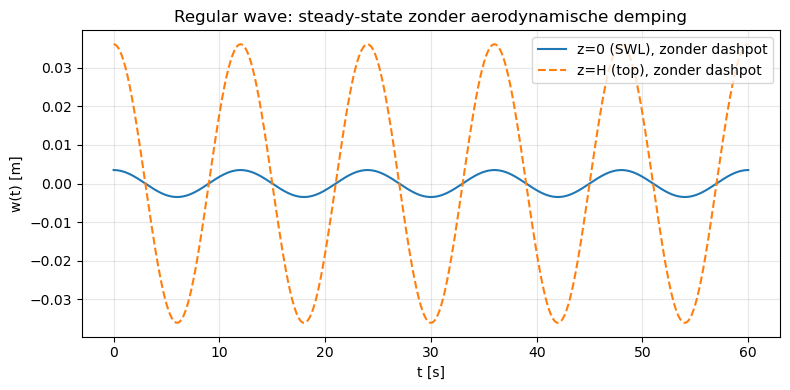

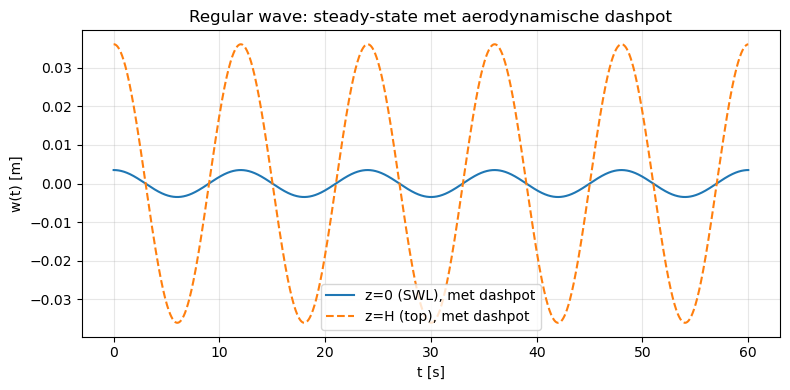

In [13]:
# -----------------------------
# Regular wave steady-state (slide-only)
# -----------------------------
omega_reg, w_swl_reg, w_top_reg = slide_harmonic_response(Tp, with_dashpot=False)
_, w_swl_reg_d, w_top_reg_d = slide_harmonic_response(Tp, with_dashpot=True)

print(f"Slide regular |w_hat(SWL)| zonder demping = {abs(w_swl_reg):.6e} m")
print(f"Slide regular |w_hat(Top)| zonder demping = {abs(w_top_reg):.6e} m")
print(f"Slide regular |w_hat(SWL)| met dashpot    = {abs(w_swl_reg_d):.6e} m")
print(f"Slide regular |w_hat(Top)| met dashpot    = {abs(w_top_reg_d):.6e} m")

t_reg = np.linspace(0.0, 5.0 * Tp, 2000)
w_swl_reg_t = np.real(w_swl_reg * np.exp(1j * omega_reg * t_reg))
w_top_reg_t = np.real(w_top_reg * np.exp(1j * omega_reg * t_reg))
w_swl_reg_d_t = np.real(w_swl_reg_d * np.exp(1j * omega_reg * t_reg))
w_top_reg_d_t = np.real(w_top_reg_d * np.exp(1j * omega_reg * t_reg))

# Stap 3: zonder aerodynamische demping, op z=0 en z=H
plt.figure(figsize=(8, 4))
plt.plot(t_reg, w_swl_reg_t, label='z=0 (SWL), zonder dashpot')
plt.plot(t_reg, w_top_reg_t, '--', label='z=H (top), zonder dashpot')
plt.xlabel('t [s]')
plt.ylabel('w(t) [m]')
plt.title('Regular wave: steady-state zonder aerodynamische demping')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Extra controle: met dashpot
plt.figure(figsize=(8, 4))
plt.plot(t_reg, w_swl_reg_d_t, label='z=0 (SWL), met dashpot')
plt.plot(t_reg, w_top_reg_d_t, '--', label='z=H (top), met dashpot')
plt.xlabel('t [s]')
plt.ylabel('w(t) [m]')
plt.title('Regular wave: steady-state met aerodynamische dashpot')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

JONSWAP RMS z=0 zonder demping = 1.341791e-02 m
JONSWAP RMS z=H zonder demping = 2.573636e-01 m
JONSWAP RMS z=0 met dashpot    = 1.030115e-02 m
JONSWAP RMS z=H met dashpot    = 1.962641e-01 m


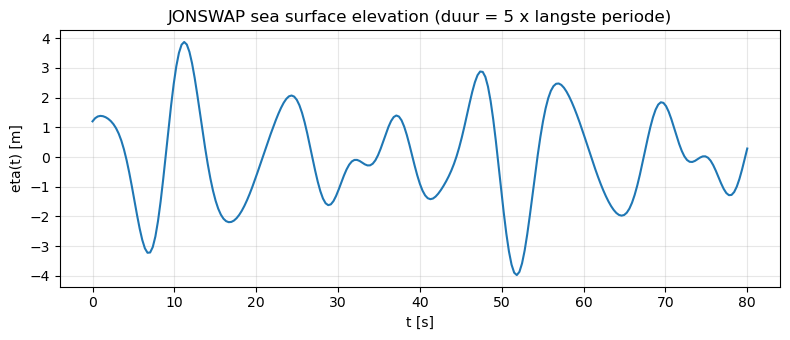

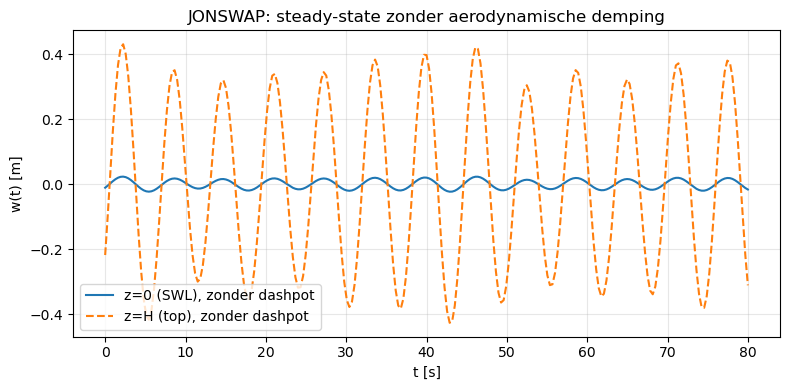

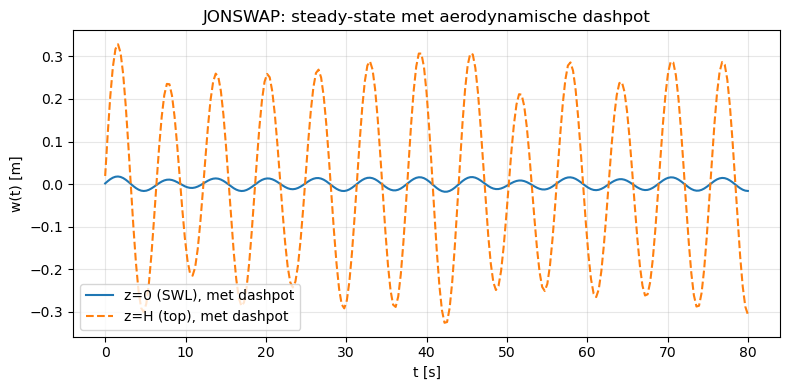

In [14]:
# -----------------------------
# JONSWAP steady-state (slide-only)
# -----------------------------
N_comp = 6
fp = 1.0 / Tp
freqs_samp = np.linspace(0.75 * fp, 2.2 * fp, N_comp)
omegas_samp = 2.0 * np.pi * freqs_samp
df = freqs_samp[1] - freqs_samp[0]
S_samp = jonswap(freqs_samp, Hs, Tp, gamma=gamma_jonswap)
amps_eta = np.sqrt(2.0 * S_samp * df)

np.random.seed(42)
phases = np.random.uniform(0.0, 2.0 * np.pi, N_comp)

T_max = 1.0 / freqs_samp[0]
t_end = 5.0 * T_max
dt = T_max / 50.0
t = np.arange(0.0, t_end + dt, dt)

eta = np.zeros_like(t)
w_swl_jonswap = np.zeros_like(t)
w_top_jonswap = np.zeros_like(t)
w_swl_jonswap_d = np.zeros_like(t)
w_top_jonswap_d = np.zeros_like(t)

for amp_i, om_i, ph_i in zip(amps_eta, omegas_samp, phases):
    Tp_i = 2.0 * np.pi / om_i
    _, w_swl_hat_i, w_top_hat_i = slide_harmonic_response(Tp_i, with_dashpot=False, a_wave=amp_i, phase=ph_i)
    _, w_swl_hat_i_d, w_top_hat_i_d = slide_harmonic_response(Tp_i, with_dashpot=True, a_wave=amp_i, phase=ph_i)

    eta += amp_i * np.cos(om_i * t + ph_i)
    w_swl_jonswap += np.real(w_swl_hat_i * np.exp(1j * om_i * t))
    w_top_jonswap += np.real(w_top_hat_i * np.exp(1j * om_i * t))
    w_swl_jonswap_d += np.real(w_swl_hat_i_d * np.exp(1j * om_i * t))
    w_top_jonswap_d += np.real(w_top_hat_i_d * np.exp(1j * om_i * t))

print(f"JONSWAP RMS z=0 zonder demping = {np.sqrt(np.mean(w_swl_jonswap**2)):.6e} m")
print(f"JONSWAP RMS z=H zonder demping = {np.sqrt(np.mean(w_top_jonswap**2)):.6e} m")
print(f"JONSWAP RMS z=0 met dashpot    = {np.sqrt(np.mean(w_swl_jonswap_d**2)):.6e} m")
print(f"JONSWAP RMS z=H met dashpot    = {np.sqrt(np.mean(w_top_jonswap_d**2)):.6e} m")

# Stap 4: zee-oppervlak
plt.figure(figsize=(8, 3.5))
plt.plot(t, eta)
plt.xlabel('t [s]')
plt.ylabel('eta(t) [m]')
plt.title('JONSWAP sea surface elevation (duur = 5 x langste periode)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stap 5: zonder aerodynamische demping, op z=0 en z=H
plt.figure(figsize=(8, 4))
plt.plot(t, w_swl_jonswap, label='z=0 (SWL), zonder dashpot')
plt.plot(t, w_top_jonswap, '--', label='z=H (top), zonder dashpot')
plt.xlabel('t [s]')
plt.ylabel('w(t) [m]')
plt.title('JONSWAP: steady-state zonder aerodynamische demping')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Stap 6: met aerodynamische dashpot, op z=0 en z=H
plt.figure(figsize=(8, 4))
plt.plot(t, w_swl_jonswap_d, label='z=0 (SWL), met dashpot')
plt.plot(t, w_top_jonswap_d, '--', label='z=H (top), met dashpot')
plt.xlabel('t [s]')
plt.ylabel('w(t) [m]')
plt.title('JONSWAP: steady-state met aerodynamische dashpot')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()